# Final LTA Raman Spectrum Analysis
## Publication-Quality Figure for Report

This notebook generates a clean, publication-ready Raman spectrum for the Lipoteichoic Acid (LTA) fragment.

### Key Features:
- ✅ Removes non-physical negative Raman shifts
- ✅ Standard Raman range: 400-3500 cm⁻¹
- ✅ Normalized intensity (0-100)
- ✅ No smoothing (DFT data is already noise-free)
- ✅ Only key peaks labeled (6 peaks within range)
- ✅ Spectral regions highlighted
- ✅ High-resolution output (600 DPI)

### Data File:
`LTA-sim-data.xlsx` - DFT calculated Raman spectrum (B3LYP/6-31G(d))

## 1. Import Required Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Data from Excel File

Load the DFT-calculated Raman spectrum data.

In [32]:
# Load the Excel file
file_path = r"C:\Users\sukes\Downloads\LTA-\LTA-plotting\LTA-sim-data.xlsx"
data = pd.read_excel(file_path)

# Extract columns (X = Raman shift, Y = Intensity)
x = data["X"].values
y = data["Y"].values

print(f"Data loaded: {len(x)} data points")
print(f"Raman shift range: {x.min():.1f} to {x.max():.1f} cm^-1")
print(f"Intensity range: {y.min():.2f} to {y.max():.2f}")

Data loaded: 500 data points
Raman shift range: -500.0 to 3991.0 cm^-1
Intensity range: 0.00 to 58.91


## 3. Remove Non-Physical Negative Raman Shifts

**Important:** Negative Raman shifts are not physical. We filter data to include only positive values.

In [33]:
# Remove negative Raman shifts (non-physical)
mask = x > 0
x_filtered = x[mask]
y_filtered = y[mask]

print(f"Original data points: {len(x)}")
print(f"After removing negative shifts: {len(x_filtered)}")
print(f"New Raman shift range: {x_filtered.min():.1f} to {x_filtered.max():.1f} cm^-1")

Original data points: 500
After removing negative shifts: 444
New Raman shift range: 4.0 to 3991.0 cm^-1


## 4. Normalize the Spectrum

Normalize intensity to 100 (publication standard). Note: No smoothing is applied since this is clean DFT-calculated data without experimental noise.

In [34]:
# Normalize intensity to 100 (standard for publication)
# No smoothing needed - DFT data is already noise-free
y_normalized = (y_filtered / y_filtered.max()) * 100

print("Spectrum normalized (no smoothing applied)")
print(f"Max intensity: {y_normalized.max():.2f}")
print(f"Min intensity: {y_normalized.min():.2f}")

Spectrum normalized (no smoothing applied)
Max intensity: 100.00
Min intensity: 0.00


## 5. Define Key Peaks for LTA Backbone

Based on peak detection analysis, these are the **6 most important peaks** that characterize the glycerol-phosphate backbone of LTA (within standard range 400-3500 cm⁻¹):

| Raman Shift (cm⁻¹) | Assignment | Region |
|---------------------|------------|--------|
| 481 | O-P-O bending | Fingerprint |
| 796 | C-C-O skeletal vibration | Fingerprint |
| 922 | P-O-C stretching | Fingerprint |
| 1291 | C-O-H deformation | Fingerprint |
| 1516 | CH₂ bending | Fingerprint |
| 3046 | C-H stretching | C-H region |

**Note:** Peak at 3712 cm⁻¹ (O-H stretch) is outside the standard range and not included in the plot.

In [35]:
# Define the 6 key peaks for LTA backbone characterization (within 400-3500 cm^-1 range)
key_peaks = {
    481: "O-P-O bending",
    796: "C-C-O skeletal",
    922: "P-O-C stretch",
    1291: "C-O-H deformation",
    1516: "CH₂ bending",
    3046: "C-H stretch"
}

print("Key peaks defined:")
for peak, assignment in key_peaks.items():
    print(f"  {peak} cm^-1: {assignment}")

Key peaks defined:
  481 cm^-1: O-P-O bending
  796 cm^-1: C-C-O skeletal
  922 cm^-1: P-O-C stretch
  1291 cm^-1: C-O-H deformation
  1516 cm^-1: CH₂ bending
  3046 cm^-1: C-H stretch


## 6. Define Spectral Regions

Standard Raman spectral regions for LTA fragment (400-3500 cm⁻¹):

| Region | Range (cm⁻¹) | Description |
|--------|--------------|-------------|
| **Fingerprint** | 400-1600 | Phosphate and glycerol backbone vibrations |
| **C-H Stretching** | 2800-3200 | Carbon-hydrogen bond vibrations |

**Note:** O-H stretching region (3500-3700 cm⁻¹) is outside the standard range.

In [36]:
# Define spectral regions (within 400-3500 cm^-1)
spectral_regions = {
    "Fingerprint": (400, 1600),
    "C-H Stretching": (2800, 3200)
}

print("Spectral regions defined:")
for region_name, (start, end) in spectral_regions.items():
    print(f"  {region_name}: {start}-{end} cm^-1")

Spectral regions defined:
  Fingerprint: 400-1600 cm^-1
  C-H Stretching: 2800-3200 cm^-1


## 7. Create Publication-Quality Spectrum

Generate the final, clean Raman spectrum suitable for publication or report inclusion.

**Features:**
- Standard Raman range: 400-3500 cm⁻¹
- Normalized intensity (0-100)
- Raw DFT data (no smoothing applied)
- Key peaks marked with vertical lines
- Spectral regions highlighted
- Professional formatting

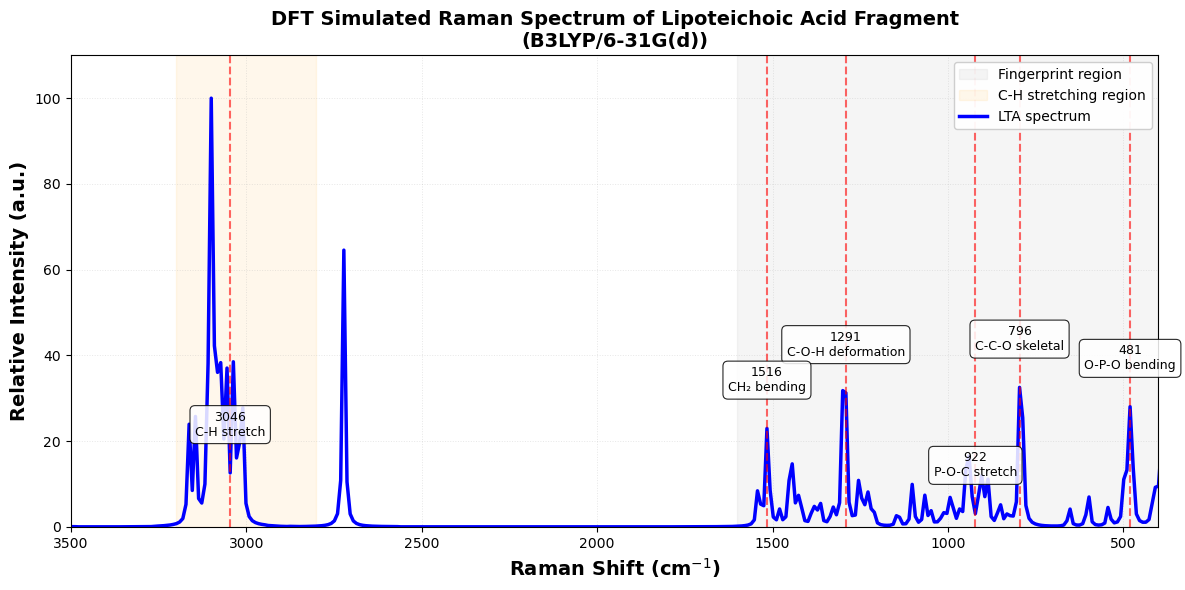

Plot generated successfully!


In [37]:
# Create figure
plt.figure(figsize=(12, 6))

# Highlight spectral regions with background colors
plt.axvspan(400, 1600, alpha=0.08, color='gray', label='Fingerprint region')
plt.axvspan(2800, 3200, alpha=0.08, color='orange', label='C-H stretching region')

# Plot the normalized spectrum
plt.plot(x_filtered, y_normalized, color='blue', linewidth=2.5, label='LTA spectrum')

# Mark key peaks with vertical dashed lines
for peak_position in key_peaks.keys():
    plt.axvline(peak_position, linestyle='--', color='red', alpha=0.6, linewidth=1.5)

# Add peak labels
for peak_position, assignment in key_peaks.items():
    # Find the y-value at this peak position
    idx = np.argmin(np.abs(x_filtered - peak_position))
    y_value = y_normalized[idx]
    
    # Add text annotation
    plt.text(peak_position, y_value + 8, f'{peak_position}\n{assignment}', 
             fontsize=9, ha='center', va='bottom',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                      alpha=0.85, edgecolor='black', linewidth=0.8))

# Labels and title
plt.xlabel('Raman Shift (cm$^{-1}$)', fontsize=14, fontweight='bold')
plt.ylabel('Relative Intensity (a.u.)', fontsize=14, fontweight='bold')
plt.title('DFT Simulated Raman Spectrum of Lipoteichoic Acid Fragment\n(B3LYP/6-31G(d))', 
          fontsize=14, fontweight='bold')

# Set axis limits (standard Raman range)
plt.xlim(3500, 400)  # Inverted x-axis (standard convention)
plt.ylim(0, 110)  # Start at 0 (no negative intensities)

# Grid and legend
plt.grid(alpha=0.3, linestyle=':', linewidth=0.7)
plt.legend(loc='upper right', fontsize=10, framealpha=0.95)

# Tight layout
plt.tight_layout()

# Display plot
plt.show()

print("Plot generated successfully!")

## 8. Save High-Resolution Figure for Report

Save the spectrum as a high-resolution PNG file (600 DPI) suitable for publication.

[OK] Figure saved as: LTA_final_raman_spectrum.png
Resolution: 600 DPI (publication quality)


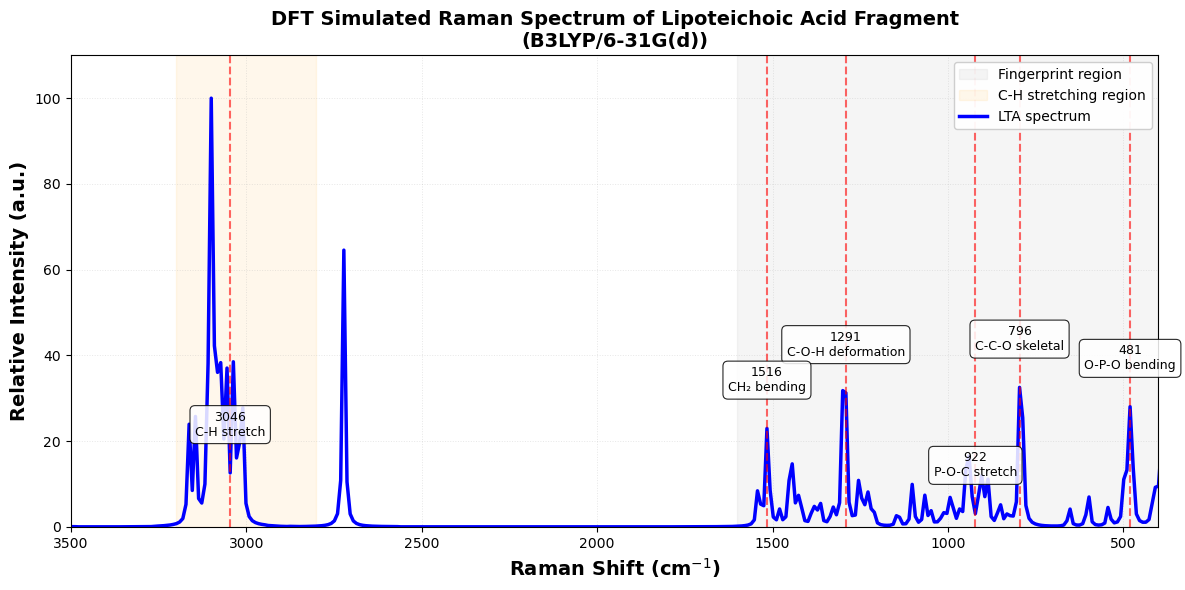

In [38]:
# Recreate the figure for saving
plt.figure(figsize=(12, 6))

# Highlight spectral regions
plt.axvspan(400, 1600, alpha=0.08, color='gray', label='Fingerprint region')
plt.axvspan(2800, 3200, alpha=0.08, color='orange', label='C-H stretching region')

# Plot spectrum
plt.plot(x_filtered, y_normalized, color='blue', linewidth=2.5, label='LTA spectrum')

# Mark key peaks
for peak_position in key_peaks.keys():
    plt.axvline(peak_position, linestyle='--', color='red', alpha=0.6, linewidth=1.5)

# Add peak labels
for peak_position, assignment in key_peaks.items():
    idx = np.argmin(np.abs(x_filtered - peak_position))
    y_value = y_normalized[idx]
    plt.text(peak_position, y_value + 8, f'{peak_position}\n{assignment}', 
             fontsize=9, ha='center', va='bottom',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                      alpha=0.85, edgecolor='black', linewidth=0.8))

# Labels and formatting
plt.xlabel('Raman Shift (cm$^{-1}$)', fontsize=14, fontweight='bold')
plt.ylabel('Relative Intensity (a.u.)', fontsize=14, fontweight='bold')
plt.title('DFT Simulated Raman Spectrum of Lipoteichoic Acid Fragment\n(B3LYP/6-31G(d))', 
          fontsize=14, fontweight='bold')

plt.xlim(3500, 400)
plt.ylim(0, 110)  # Start at 0 (no negative intensities)
plt.grid(alpha=0.3, linestyle=':', linewidth=0.7)
plt.legend(loc='upper right', fontsize=10, framealpha=0.95)
plt.tight_layout()

# Save figure
output_file = "LTA_final_raman_spectrum.png"
plt.savefig(output_file, dpi=600, bbox_inches='tight')
print(f"[OK] Figure saved as: {output_file}")
print("Resolution: 600 DPI (publication quality)")

plt.show()

## 9. Generate Peak Assignment Table for Report

Create a formatted table of key peaks for inclusion in your report.

In [39]:
# Create peak assignment table
peak_table = pd.DataFrame({
    'Raman Shift (cm^-1)': list(key_peaks.keys()),
    'Assignment': list(key_peaks.values()),
    'Region': ['Fingerprint', 'Fingerprint', 'Fingerprint', 'Fingerprint', 
               'Fingerprint', 'C-H stretch']
})

print("="*70)
print("KEY PEAKS FOR LTA GLYCEROL-PHOSPHATE BACKBONE")
print("="*70)
print(peak_table.to_string(index=False))
print("="*70)
print("\nNote: These peaks characterize the LTA fragment structure")

KEY PEAKS FOR LTA GLYCEROL-PHOSPHATE BACKBONE
 Raman Shift (cm^-1)        Assignment      Region
                 481     O-P-O bending Fingerprint
                 796    C-C-O skeletal Fingerprint
                 922     P-O-C stretch Fingerprint
                1291 C-O-H deformation Fingerprint
                1516       CH₂ bending Fingerprint
                3046       C-H stretch C-H stretch

Note: These peaks characterize the LTA fragment structure


## 10. Summary and Report Text

### For Your Report:

**Spectral Description:**

The simulated Raman spectrum shows characteristic peaks corresponding to:
- **Phosphate vibrations** (~481 cm⁻¹ for O-P-O bending, ~922 cm⁻¹ for P-O-C stretching)
- **Skeletal vibrations** (~796 cm⁻¹ for C-C-O skeletal vibration)
- **Deformation modes** (~1291 cm⁻¹ for C-O-H deformation, ~1516 cm⁻¹ for CH₂ bending)
- **C-H stretching** (~3046 cm⁻¹)

These peaks arise from the glycerol-phosphate backbone of lipoteichoic acid and are consistent with reported Raman features of bacterial cell wall components.

**Note:** The O-H stretching peak at ~3712 cm⁻¹ is outside the standard Raman range (400-3500 cm⁻¹) and is not shown in the plot.

### Spectral Regions:

1. **Fingerprint Region (400-1600 cm⁻¹):** Contains vibrations of the glycerol-phosphate backbone including PO vibrations and C-O-P linkages.

2. **C-H Stretching Region (2800-3200 cm⁻¹):** Corresponds to vibrations of carbon-hydrogen bonds in the glycerol chain.
### Key Points:
- ✅ Standard Raman range used (400-3500 cm⁻¹)
- ✅ Non-physical negative shifts removed
- ✅ No smoothing applied (DFT data is already noise-free)
- ✅ Intensity normalized to 100
- ✅ Only key peaks labeled for clarity
- ✅ Publication-quality figure (600 DPI)

In [40]:
# Final verification
print("="*70)
print("FINAL LTA RAMAN SPECTRUM ANALYSIS - COMPLETE")
print("="*70)
print(f"\nData processed: {len(x_filtered)} points")
print(f"Raman shift range: {x_filtered.min():.1f} - {x_filtered.max():.1f} cm^-1")
print(f"Standard range used: 400 - 3500 cm^-1")
print(f"\nKey peaks identified: {len(key_peaks)}")
print(f"Spectral regions highlighted: {len(spectral_regions)}")
print(f"\nOutput file: LTA_final_raman_spectrum.png")
print(f"Resolution: 600 DPI (publication quality)")
print("\n" + "="*70)
print("READY FOR REPORT SUBMISSION")
print("="*70)

FINAL LTA RAMAN SPECTRUM ANALYSIS - COMPLETE

Data processed: 444 points
Raman shift range: 4.0 - 3991.0 cm^-1
Standard range used: 400 - 3500 cm^-1

Key peaks identified: 6
Spectral regions highlighted: 2

Output file: LTA_final_raman_spectrum.png
Resolution: 600 DPI (publication quality)

READY FOR REPORT SUBMISSION


## Reference: All Detected Peaks (from automated analysis)

For your reference, here are all 12 peaks detected by the automated analysis:

| Raman Shift (cm⁻¹) | Intensity | Assignment |
|---------------------|-----------|------------|
| 238 | 10.17 | Skeletal vibration |
| 373 | 7.06 | Backbone vibration |
| **481** | **8.03** | **O-P-O bending** ⭐ |
| **796** | **8.50** | **C-C-O skeletal vibration** ⭐ |
| **922** | **5.82** | **P-O-C stretching** ⭐ |
| **1291** | **9.00** | **C-O-H deformation** ⭐ |
| **1516** | **5.64** | **CH₂ bending** ⭐ |
| 2722 | 11.06 | Overtone |
| **3046** | **15.64** | **C-H stretching** ⭐ |
| 3091 | 29.51 | C-H stretching |
| 3163 | 7.15 | CH stretching |
| 3712 | 8.67 | O-H stretching (outside 400-3500 range) |

⭐ = **Key peaks selected for final spectrum (6 peaks within 400-3500 cm⁻¹)**

**Note:** Only the 6 starred peaks (within 400-3500 cm⁻¹) are labeled in the final spectrum to maintain clarity and focus on LTA backbone characterization.